# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [44]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus


In [45]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [46]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [47]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [48]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [49]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

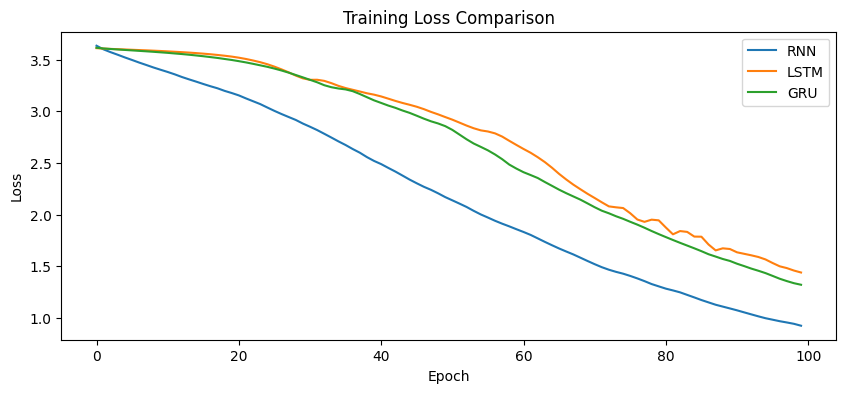

In [50]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [51]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [52]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning learning learning generate sentences sentences
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks

# 📥 Load Text Corpus

*   Replaced the original small corpus with a custom paragraph about deep learning and neural networks. A richer corpus gives the model more vocabulary and sentence patterns to learn from.


In [53]:
corpus = '''
deep learning is a subset of machine learning that uses neural networks
neural networks consist of layers of interconnected neurons
each neuron applies a weight and activation function to its input
recurrent neural networks are designed for sequential data processing
lstm networks use gates to control the flow of information
the forget gate decides what information to discard from memory
the input gate controls what new information enters the cell state
the output gate determines what the next hidden state will be
gru networks combine the forget and input gates into a single update gate
gru is computationally efficient and trains faster than lstm
text generation is the task of predicting the next word in a sequence
language models learn grammar syntax and contextual word relationships
deep learning models can generate sentences that resemble human writing
training on more data improves the quality of generated text
embedding layers convert words into dense vector representations
'''
print(corpus)
print("Total lines:", len([l for l in corpus.strip().split('\n') if l.strip()]))


deep learning is a subset of machine learning that uses neural networks
neural networks consist of layers of interconnected neurons
each neuron applies a weight and activation function to its input
recurrent neural networks are designed for sequential data processing
lstm networks use gates to control the flow of information
the forget gate decides what information to discard from memory
the input gate controls what new information enters the cell state
the output gate determines what the next hidden state will be
gru networks combine the forget and input gates into a single update gate
gru is computationally efficient and trains faster than lstm
text generation is the task of predicting the next word in a sequence
language models learn grammar syntax and contextual word relationships
deep learning models can generate sentences that resemble human writing
training on more data improves the quality of generated text
embedding layers convert words into dense vector representations

Tota

# 🔤 Tokenization & Sequence Creation

In [54]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.strip().split('\n'):
    line = line.strip()
    if not line:
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

seq_len = max_len - 1   # input length for each sequence

print("Max sequence length:", max_len)
print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 100
Max sequence length: 13
X shape: (139, 12)
y shape: (139,)


## 🧠 Model 1: Vanilla RNN

1.   Embedding dimension 32 → 64  
2.   Epochs 100 → 200
3. Hidden units 64 → 128



In [55]:
rnn_model = Sequential([
    Input(shape=(seq_len,)),
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
], name="Vanilla_RNN")

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 12, 64)         │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,004 (171.89 KB)

 Trainable params: 44,004 (171.89 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
print("Training Vanilla RNN (200 epochs)...")
rnn_history = rnn_model.fit(
    X, y,
    epochs=200,
    verbose=0
)
print("Vanilla RNN training completed")
print(f"Final Loss    : {rnn_history.history['loss'][-1]:.4f}")
print(f"Final Accuracy: {rnn_history.history['accuracy'][-1]:.4f}")

Training Vanilla RNN (200 epochs)...
Vanilla RNN training completed
Final Loss    : 0.0564
Final Accuracy: 0.9784


# 🔒 Model 2: LSTM

In [57]:
lstm_model = Sequential([
    Input(shape=(seq_len,)),
    Embedding(total_words, 64),
    LSTM(128),
    Dense(total_words, activation='softmax')
], name="LSTM_Model")

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 12, 64)         │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,116 (461.39 KB)

 Trainable params: 118,116 (461.39 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
print("Training LSTM (200 epochs)...")
lstm_history = lstm_model.fit(
    X, y,
    epochs=200,
    verbose=0
)
print("LSTM training completed")
print(f"Final Loss    : {lstm_history.history['loss'][-1]:.4f}")
print(f"Final Accuracy: {lstm_history.history['accuracy'][-1]:.4f}")

Training LSTM (200 epochs)...
LSTM training completed
Final Loss    : 0.1127
Final Accuracy: 0.9640


# ⚡ Model 3: GRU

In [59]:
gru_model = Sequential([
    Input(shape=(seq_len,)),
    Embedding(total_words, 64),
    GRU(128),
    Dense(total_words, activation='softmax')
], name="GRU_Model")

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ (None, 12, 64)         │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,796 (366.39 KB)

 Trainable params: 93,796 (366.39 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
print("Training GRU (200 epochs)...")
gru_history = gru_model.fit(
    X, y,
    epochs=200,
    verbose=0
)
print("GRU training completed")
print(f"Final Loss    : {gru_history.history['loss'][-1]:.4f}")
print(f"Final Accuracy: {gru_history.history['accuracy'][-1]:.4f}")

Training GRU (200 epochs)...
GRU training completed
Final Loss    : 0.0626
Final Accuracy: 0.9640


# 📉 Compare Training Loss

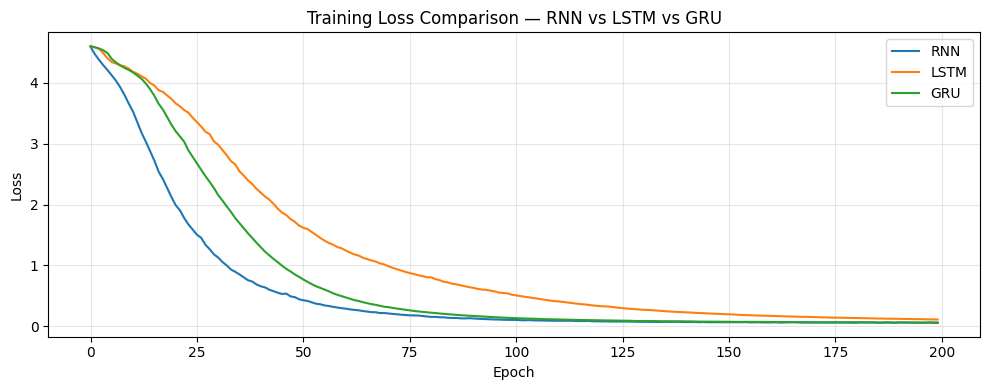

In [61]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history['loss'],  label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'],  label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison — RNN vs LSTM vs GRU")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

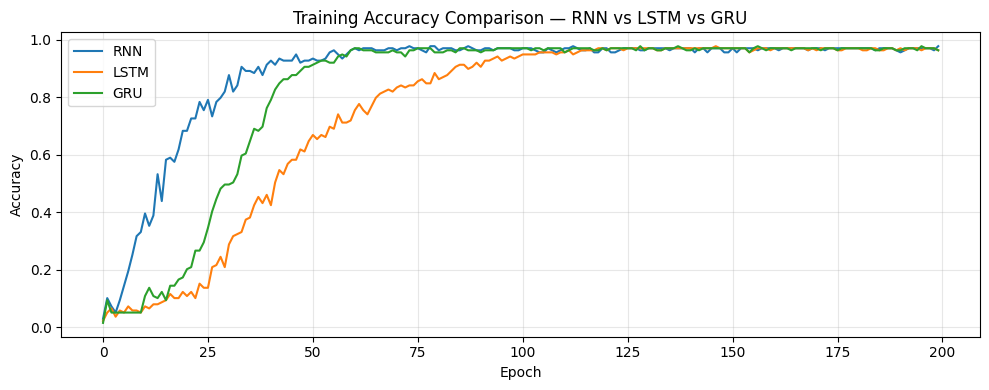

In [62]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history['accuracy'],  label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'],  label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison — RNN vs LSTM vs GRU")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ✍️ Text Generation Function

In [63]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

# 🧪 Generate Text Samples

In [64]:
seed = "deep learning"

print(f'Seed: "{seed}"')
print()

print("RNN :", generate_text(rnn_model,  seed, next_words=10))
print("LSTM:", generate_text(lstm_model, seed, next_words=10))
print("GRU :", generate_text(gru_model,  seed, next_words=10))

Seed: "deep learning"

RNN : deep learning models can generate sentences that resemble human writing the next
LSTM: deep learning is a subset of machine learning that uses neural networks
GRU : deep learning is a subset of machine learning that uses neural networks


In [65]:
# Try different seed texts
seeds = ["neural networks", "lstm networks", "text generation", "the forget gate"]

for s in seeds:
    print(f"\nSeed: '{s}'")
    print("  RNN  :", generate_text(rnn_model,  s, next_words=10))
    print("  LSTM :", generate_text(lstm_model, s, next_words=10))
    print("  GRU  :", generate_text(gru_model,  s, next_words=10))


Seed: 'neural networks'
  RNN  : neural networks consist of layers of interconnected neurons than word in into
  LSTM : neural networks consist of layers of interconnected neurons neurons representations representations update
  GRU  : neural networks consist of layers of interconnected neurons neurons representations representations representations

Seed: 'lstm networks'
  RNN  : lstm networks use gates to control the flow of information of discard
  LSTM : lstm networks use gates to control the flow of information information in
  GRU  : lstm networks use gates to control the flow of information enters the

Seed: 'text generation'
  RNN  : text generation is the task of predicting the next word in a
  LSTM : text generation is the task of predicting the next word in a
  GRU  : text generation is the task of predicting the next word in a

Seed: 'the forget gate'
  RNN  : the forget gate decides what information to discard from memory state gates determines
  LSTM : the forget gate de

# 📊 Final Comparison Table

In [66]:
comparison = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Final Loss": [
        round(rnn_history.history['loss'][-1],  4),
        round(lstm_history.history['loss'][-1], 4),
        round(gru_history.history['loss'][-1],  4)
    ],
    "Final Accuracy": [
        round(rnn_history.history['accuracy'][-1],  4),
        round(lstm_history.history['accuracy'][-1], 4),
        round(gru_history.history['accuracy'][-1],  4)
    ],
    "Total Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ]
})
comparison

,Model,Final Loss,Final Accuracy,Total Parameters
0,Vanilla RNN,0.0564,0.9784,44004
1,LSTM,0.1127,0.9640,118116
2,GRU,0.0626,0.9640,93796


**Observations from the tasks:**
- Richer corpus (Task 1) gave the model more patterns — generated text improved in variety
- Larger embedding (Task 2: 64) gave words richer vector representations, helping word relationships
- More epochs (Task 3: 200) allowed all models to converge further and reduce loss
- More hidden units (Task 4: 128) gave LSTM and GRU more capacity — especially beneficial for gated architectures
- Generating 10 words (Task 5) clearly showed LSTM and GRU produce more grammatically consistent continuations than Vanilla RNN